# Time Series Forecasting: LSTM for Stock Price Prediction (PyTorch)

This notebook builds a next-day closing price predictor using an LSTM over a single stock's historical closing prices. Dataset: daily closing prices for a chosen ticker, downloaded via `yfinance`.

Same overall pipeline style as the CNN notebook, adapted for sequential/time-series data:
1. Get the data
2. Profile the data
3. Split into train / validation / test — **chronologically**, not randomly (time series must preserve order)
4. Scale the data (fit only on train, to avoid leakage)
5. Wrap into a PyTorch Dataset using a sliding window
6. Build the model: LSTM -> final hidden state -> Dropout -> Linear
7. Train, tracking train vs. validation loss each epoch
8. Final evaluation on the held-out test set (plus a dollar-scale RMSE and an actual-vs-predicted plot)
9. Inference: predict the next closing price from the most recent window
10. Save the model

The key differences from the image notebook: this is regression, not classification (so no accuracy metric — just loss and RMSE), and the train/val/test split must respect time order to avoid leaking future information into the past.


## 0. Install & Import Libraries

In [1]:
# !pip install yfinance scikit-learn torch matplotlib --quiet

import random
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import yfinance as yf
from sklearn.preprocessing import MinMaxScaler

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 1. Get the Data

Download daily closing prices for a single ticker via `yfinance`. We only keep the `Close` column — this notebook predicts future closing price from past closing price, so we don't need Open/High/Low/Volume.

In [3]:
TICKER = "AAPL"
START_DATE = "2015-01-01"
END_DATE = "2024-12-31"

raw_df = yf.download(TICKER, start=START_DATE, end=END_DATE)
raw_df = raw_df[["Close"]].dropna()
raw_df.columns = ["Close"]

print("Ticker:", TICKER)
print("Date range:", raw_df.index.min().date(), "to", raw_df.index.max().date())
print("Total trading days:", len(raw_df))
raw_df.head()


[*********************100%***********************]  1 of 1 completed

Ticker: AAPL
Date range: 2015-01-02 to 2024-12-30
Total trading days: 2515


,Close
Date,
2015-01-02,24.192606
2015-01-05,23.511051
2015-01-06,23.513269
2015-01-07,23.842978
2015-01-08,24.759083


## 2. Profile the Data

Look at the overall trend and basic stats before building anything — same purpose as the image profiling step, catching obvious issues early (missing days, weird jumps, unexpected ranges).

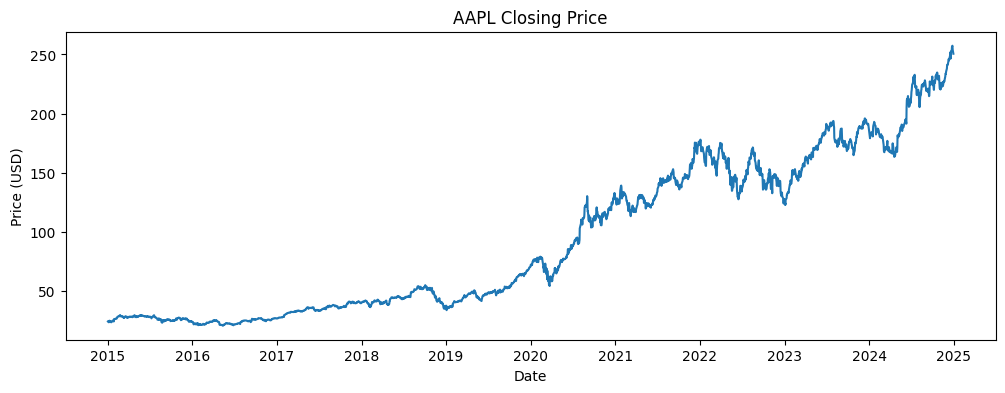

Price stats:
count    2515.000000
mean       93.623190
std        65.259577
min        20.565866
25%        35.138058
50%        64.254387
75%       149.941132
max       257.375610
Name: Close, dtype: float64

Missing values: 0


In [4]:
plt.figure(figsize=(12, 4))
plt.plot(raw_df.index, raw_df["Close"])
plt.title(f"{TICKER} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

print("Price stats:")
print(raw_df["Close"].describe())
print("\nMissing values:", raw_df["Close"].isna().sum())


## 3. Split into Train / Validation / Test

Unlike the image classification notebook — where examples are independent and a random stratified split is fine — time series data has temporal order that must be preserved. Shuffling before splitting would leak future information into training (the model would effectively be validated/tested on days whose "future" it already learned from).

Instead we split **chronologically**: earliest 70% of days -> train, next 15% -> validation, final 15% -> test (the most recent days — closest to a realistic "deploy this and predict tomorrow" scenario).

In [5]:
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
# remaining ~0.15 goes to test

total_len = len(raw_df)
train_end = int(total_len * TRAIN_FRAC)
val_end = int(total_len * (TRAIN_FRAC + VAL_FRAC))

train_df = raw_df.iloc[:train_end]
val_df = raw_df.iloc[train_end:val_end]
test_df = raw_df.iloc[val_end:]

print(f"Train: {train_df.index.min().date()} -> {train_df.index.max().date()}  ({len(train_df)} days)")
print(f"Val  : {val_df.index.min().date()} -> {val_df.index.max().date()}  ({len(val_df)} days)")
print(f"Test : {test_df.index.min().date()} -> {test_df.index.max().date()}  ({len(test_df)} days)")


Train: 2015-01-02 -> 2021-12-28  (1760 days)
Val  : 2021-12-29 -> 2023-06-29  (377 days)
Test : 2023-06-30 -> 2024-12-30  (378 days)


## 4. Scale the Data

LSTMs (like most neural nets) train more stably on small, roughly-uniform-scale inputs than on raw dollar prices. We use `MinMaxScaler` to rescale prices into `[0, 1]`.

**Important: fit the scaler on train data only.** If we fit it on the full series (train+val+test), the min/max of the validation and test periods would leak into the scaler's parameters — a subtle form of the same leakage problem the chronological split above is trying to avoid. Val/test are transformed using the train-fitted scaler, so their scaled values may fall slightly outside `[0, 1]` if the stock reached new highs/lows after the training period — that's expected and fine.

In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_df[["Close"]])  # fit ONLY on train

train_scaled = scaler.transform(train_df[["Close"]]).flatten()
val_scaled = scaler.transform(val_df[["Close"]]).flatten()
test_scaled = scaler.transform(test_df[["Close"]]).flatten()

print("Train scaled range:", train_scaled.min(), "-", train_scaled.max())
print("Val scaled range  :", val_scaled.min(), "-", val_scaled.max())
print("Test scaled range :", test_scaled.min(), "-", test_scaled.max())


Train scaled range: 0.0 - 1.0000000000000002
Val scaled range  : 0.6573346823906778 - 1.068525273998032
Test scaled range : 0.9169345754586423 - 1.520629041282431


## 5. Sliding-Window Dataset

LSTMs consume fixed-length sequences. We slide a window of length `SEQ_LEN` over the scaled price series: each sample is `SEQ_LEN` consecutive days as input, and the very next day's price as the target. This plays the same role the `ImageClassificationDataset` played for images — same lazy `__getitem__` pattern, just windowing over a 1-D signal instead of loading an image from disk.

Windows are built **separately within each split** (train/val/test), so no window ever spans across a split boundary.

In [7]:
class TimeSeriesWindowDataset(Dataset):
    """Wraps a 1-D scaled price series into (sequence, next_value) samples using a sliding window."""

    def __init__(self, series, seq_len):
        self.series = series
        self.seq_len = seq_len

    def __len__(self):
        return len(self.series) - self.seq_len

    def __getitem__(self, idx):
        x = self.series[idx: idx + self.seq_len]
        y = self.series[idx + self.seq_len]
        return {
            "sequence": torch.tensor(x, dtype=torch.float32).unsqueeze(-1),  # (seq_len, 1)
            "target": torch.tensor(y, dtype=torch.float32),
        }


SEQ_LEN = 30  # use the last 30 trading days to predict the next day's close

train_dataset = TimeSeriesWindowDataset(train_scaled, SEQ_LEN)
val_dataset = TimeSeriesWindowDataset(val_scaled, SEQ_LEN)
test_dataset = TimeSeriesWindowDataset(test_scaled, SEQ_LEN)

print("Train windows:", len(train_dataset))
print("Val windows  :", len(val_dataset))
print("Test windows :", len(test_dataset))

sample = train_dataset[0]
print("sequence shape:", sample["sequence"].shape, "| target:", sample["target"].item())


Train windows: 1730
Val windows  : 347
Test windows : 348
sequence shape: torch.Size([30, 1]) | target: 0.050292130559682846


In [9]:
BATCH_SIZE = 64

# Shuffling here is safe: each window is still an intact, correctly-ordered chunk of the past.
# Shuffling only changes the *order the model sees windows in during training* — it does not
# reorder the days inside a window, and it never mixes train/val/test data together.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
print("sequence batch shape:", batch["sequence"].shape)   # (batch, seq_len, 1)
print("target batch shape  :", batch["target"].shape)


sequence batch shape: torch.Size([64, 30, 1])
target batch shape  : torch.Size([64])


## 6. Build the Model: LSTM

- `nn.LSTM(input_size=1, hidden_size=H, num_layers=L, batch_first=True)`: processes the sequence one day at a time, maintaining a hidden state that carries information forward through the window. This plays the same architectural role the `Conv2d` blocks played in the CNN notebook — progressively building a useful representation — but over a sequence instead of a grid of pixels.
- We only need the **final hidden state** (the summary after having seen all `SEQ_LEN` days) to make the prediction — conceptually similar to `AdaptiveAvgPool2d` collapsing the CNN's feature maps into one vector before the classifier head.
- **Regression head**: `Dropout -> Linear(hidden_size, 1)`, mapping the final hidden state to a single scalar (the predicted next-day scaled price) — same shape as the CNN's classifier head, but outputting one continuous value instead of `num_labels` logits.

In [10]:
class LSTMPricePredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.regressor_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, sequences):
        # sequences: (batch, seq_len, input_size)
        lstm_out, (h_n, c_n) = self.lstm(sequences)
        last_hidden = h_n[-1]                                   # (batch, hidden_size) — final layer's last hidden state
        prediction = self.regressor_head(last_hidden).squeeze(-1)  # (batch,)
        return prediction


In [11]:
model = LSTMPricePredictor(
    input_size=1,
    hidden_size=64,
    num_layers=2,
    dropout=0.2,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Total params: 50,497
Trainable params: 50,497


## 7. Loss Function & Optimizer

Regression task -> `MSELoss` (mean squared error) instead of `CrossEntropyLoss`.

In [12]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


## 8. Training Loop

In [14]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)
    for batch in progress_bar:
        sequences = batch["sequence"].to(device)
        targets = batch["target"].to(device)

        optimizer.zero_grad()
        preds = model(sequences)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * targets.size(0)
        total += targets.size(0)

        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / total
    return avg_loss


In [15]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0

    progress_bar = tqdm(loader, desc="Evaluating", leave=False)
    for batch in progress_bar:
        sequences = batch["sequence"].to(device)
        targets = batch["target"].to(device)

        preds = model(sequences)
        loss = criterion(preds, targets)

        total_loss += loss.item() * targets.size(0)
        total += targets.size(0)

        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / total
    return avg_loss


In [16]:
NUM_EPOCHS = 30

history = []

for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs"):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)   # validation, NOT test

    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

    print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")


Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Training:   0%|          | 0/28 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 0.058900 | Val Loss: 0.054787


Training:   0%|          | 0/28 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 29/30 | Train Loss: 0.000842 | Val Loss: 0.001245


Training:   0%|          | 0/28 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss: 0.000901 | Val Loss: 0.001136


## 8a. Plot Training & Validation Curves

Only loss is plotted here — regression doesn't have a natural "accuracy" the way classification does. A widening gap between train and val loss is still the same overfitting signature as before.

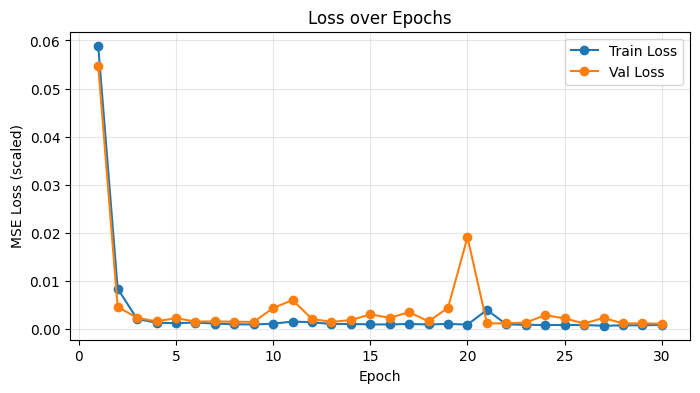

In [17]:
epochs = [h["epoch"] for h in history]
train_losses = [h["train_loss"] for h in history]
val_losses = [h["val_loss"] for h in history]

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, label="Train Loss", marker="o")
plt.plot(epochs, val_losses, label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (scaled)")
plt.title("Loss over Epochs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 8b. Final Evaluation on the Held-Out Test Set

Run this **once**, after training/tuning is finished — the test set (the most recent days) was never seen during training or used to make decisions about epochs/hyperparameters. We report loss in scaled units, plus RMSE in real dollars (via `scaler.inverse_transform`) since "0.003 MSE" isn't very interpretable on its own.

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Final Test Loss (MSE, scaled): 0.005310
Test RMSE: $11.35


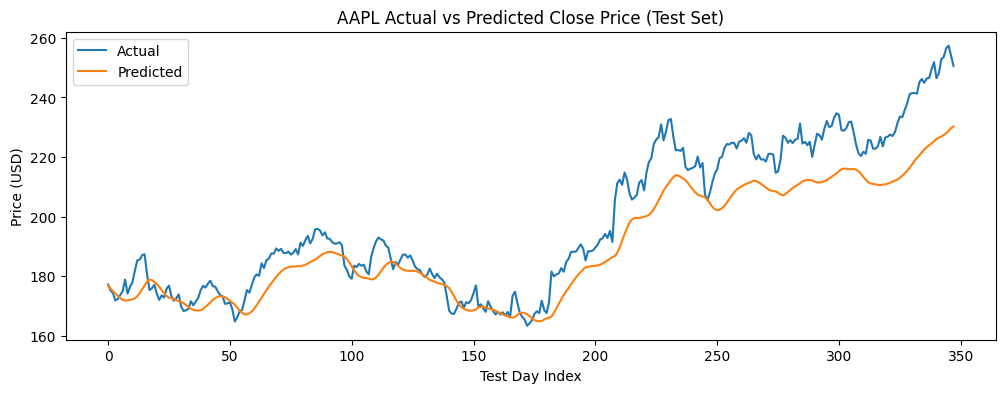

In [18]:
test_loss = evaluate(model, test_loader, criterion, device)
print(f"Final Test Loss (MSE, scaled): {test_loss:.6f}")


@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for batch in loader:
        sequences = batch["sequence"].to(device)
        preds = model(sequences).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(batch["target"].numpy())
    return np.concatenate(all_preds), np.concatenate(all_targets)


test_preds_scaled, test_targets_scaled = collect_predictions(model, test_loader, device)

# Inverse-transform back to real dollar prices
test_preds = scaler.inverse_transform(test_preds_scaled.reshape(-1, 1)).flatten()
test_targets = scaler.inverse_transform(test_targets_scaled.reshape(-1, 1)).flatten()

rmse_dollars = np.sqrt(np.mean((test_preds - test_targets) ** 2))
print(f"Test RMSE: ${rmse_dollars:.2f}")

plt.figure(figsize=(12, 4))
plt.plot(test_targets, label="Actual")
plt.plot(test_preds, label="Predicted")
plt.xlabel("Test Day Index")
plt.ylabel("Price (USD)")
plt.title(f"{TICKER} Actual vs Predicted Close Price (Test Set)")
plt.legend()
plt.show()


## 9. Inference on New Data

Given the most recent `SEQ_LEN` days of *raw* (unscaled) closing prices, predict the next day's closing price.

In [22]:
def predict_next_price(recent_prices, model, scaler, seq_len, device):
    """recent_prices: array-like of the most recent `seq_len` raw closing prices, oldest first."""
    model.eval()

    recent_prices = np.array(recent_prices).reshape(-1, 1)
    assert len(recent_prices) == seq_len, f"Expected {seq_len} prices, got {len(recent_prices)}"

    scaled = scaler.transform(recent_prices).flatten()
    sequence = torch.tensor(scaled, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)  # (1, seq_len, 1)

    with torch.no_grad():
        pred_scaled = model(sequence).cpu().item()

    pred_price = scaler.inverse_transform([[pred_scaled]])[0, 0]
    return pred_price


# Quick check: use the last SEQ_LEN days of the test set to predict the day right after it
last_window_raw = test_df["Close"].values[-SEQ_LEN:]
predicted_next = predict_next_price(last_window_raw, model, scaler, SEQ_LEN, device)

print(f"Last known close   : ${last_window_raw[-1]:.2f}")
print(f"Predicted next close: ${predicted_next:.2f}")

# To predict from a custom list of prices instead:
# predicted_next = predict_next_price([171.2, 172.5, ...], model, scaler, SEQ_LEN, device)


Last known close   : $250.60
Predicted next close: $230.45


d:\miniconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


## 10. Save the Model (optional)

Saves the full model state dict, plus the fitted scaler, so you can reload both later without retraining or re-fitting.

In [18]:
import joblib

torch.save(model.state_dict(), "lstm_price_predictor.pt")
joblib.dump(scaler, "lstm_price_scaler.joblib")
print("Model saved to lstm_price_predictor.pt")
print("Scaler saved to lstm_price_scaler.joblib")

# To reload later:
# model = LSTMPricePredictor(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)
# model.load_state_dict(torch.load("lstm_price_predictor.pt", map_location=device))
# model.to(device)
# scaler = joblib.load("lstm_price_scaler.joblib")


Model saved to lstm_price_predictor.pt
Scaler saved to lstm_price_scaler.joblib
